M505 Introduction to AI and Machine Learning
Individual Project: Building and Evaluating a Machine Learning Pipeline using the Bank Marketing Dataset

Student Name: Deepak Sindhu

Student ID: GH1056312

Module: M505 Introduction to AI and Machine Learning

University: GISMA University of Applied Sciences

Submission Date: 18th September 2026
**Github Repo** https://github.com/deepak324/python/tree/main/venv/bank_project


1. Introduction

One of the most important methods for banks to connect with their customers is  digital marketing. Banks  use phone campaigns to connect to consumers in order to advertise thier products like term deposits etc. While, it takes a lot of time to connect with every customer. Machine learning can help banks to find customers who wants to buy any product, so they can contact them.

In this project, i uses the Bank Marketing Dataset to build a complete machine learning system. The pipeline covers all things from collecting and exploring data, to cleaning and preparing it, creating new features, training models, fine-tuning  and  checking how well they perform using different machine learning techniques. My goal is to build a model that can correctly predict which customers are interested to open a term deposit.

This project follows the standard machine learning process recommended in the M505 evaluation brief. the Scikit-learn library is used for preparing the data or building the models and checking their performance. I find the best approach for this classification task.

2. Problem Definition
Business Problem

Banks used lot of resources on direct marketing campaigns. Connect with customers who are unlikely to subscribe increases operational costs and reduces marketing efficiency. Hence, observe customer responses before launching a campaign can improve decision-making and increase campaign success.

Machine Learning Problem

This is a binary classification problem.

The objective is to predict whether a customer will subscribe to a term deposit after being contacted during a marketing campaign.

Target Variable
y

Possible values
yes
no

Input Features

The prediction is based on customer demographic information, financial information, previous campaign history and communication details.

Examples include

Age
Job
Marital Status
Education
Balance
Housing Loan
Personal Loan
Contact Method
Campaign
Previous Outcome
Why is this problem important?

Accurate prediction enables banks to

Reduce marketing costs
Improve customer targeting
Increase campaign effectiveness
Save employee time
Improve customer satisfaction

3. Dataset Description
Dataset Name

Bank Marketing Dataset

Dataset Source

UCI Machine Learning Repository

Dataset Link

https://archive.ics.uci.edu/ml/datasets/bank+marketing

Alternative OpenML Dataset

https://www.openml.org/d/1461

Dataset Creator

Moro, Rita, and Cortez

License

Public Research Dataset

Machine Learning Task

Binary Classification

Number of Records

45,211

Number of Features

16 Input Features

1 Target Variable

Target Variable

y

Values

yes
no

4. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

5. Load Dataset

In [4]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


6. Display Dataset Information

In [15]:
df.shape

(45211, 17)

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


7. Display Sample Records

In [16]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
43508,74,retired,married,tertiary,no,4912,no,no,telephone,20,apr,268,2,181,3,failure,no
16155,26,management,single,secondary,no,-38,no,no,cellular,22,jul,443,2,-1,0,unknown,no
3913,60,management,married,tertiary,no,36,yes,no,unknown,16,may,194,3,-1,0,unknown,no
22638,60,retired,married,unknown,no,963,no,no,cellular,22,aug,148,10,-1,0,unknown,no
8789,31,blue-collar,single,secondary,no,-173,yes,no,unknown,4,jun,121,2,-1,0,unknown,no


8. Check Missing Values

In [9]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

9. Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

10. Descriptive Statistics

In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


11. Class Distribution

In [14]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

12. Visualize Target Variable

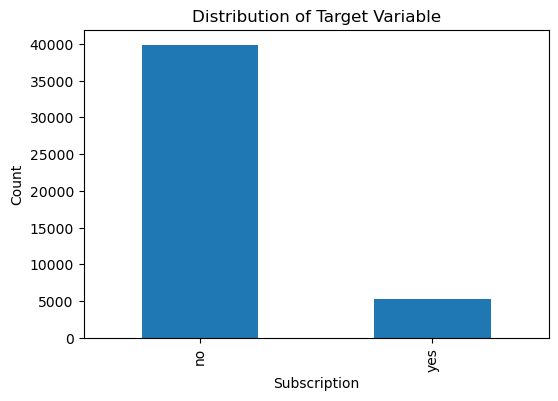

In [17]:
plt.figure(figsize=(6,4))
df["y"].value_counts().plot(kind="bar")
plt.title("Distribution of Target Variable")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

13. Numerical Feature Distribution

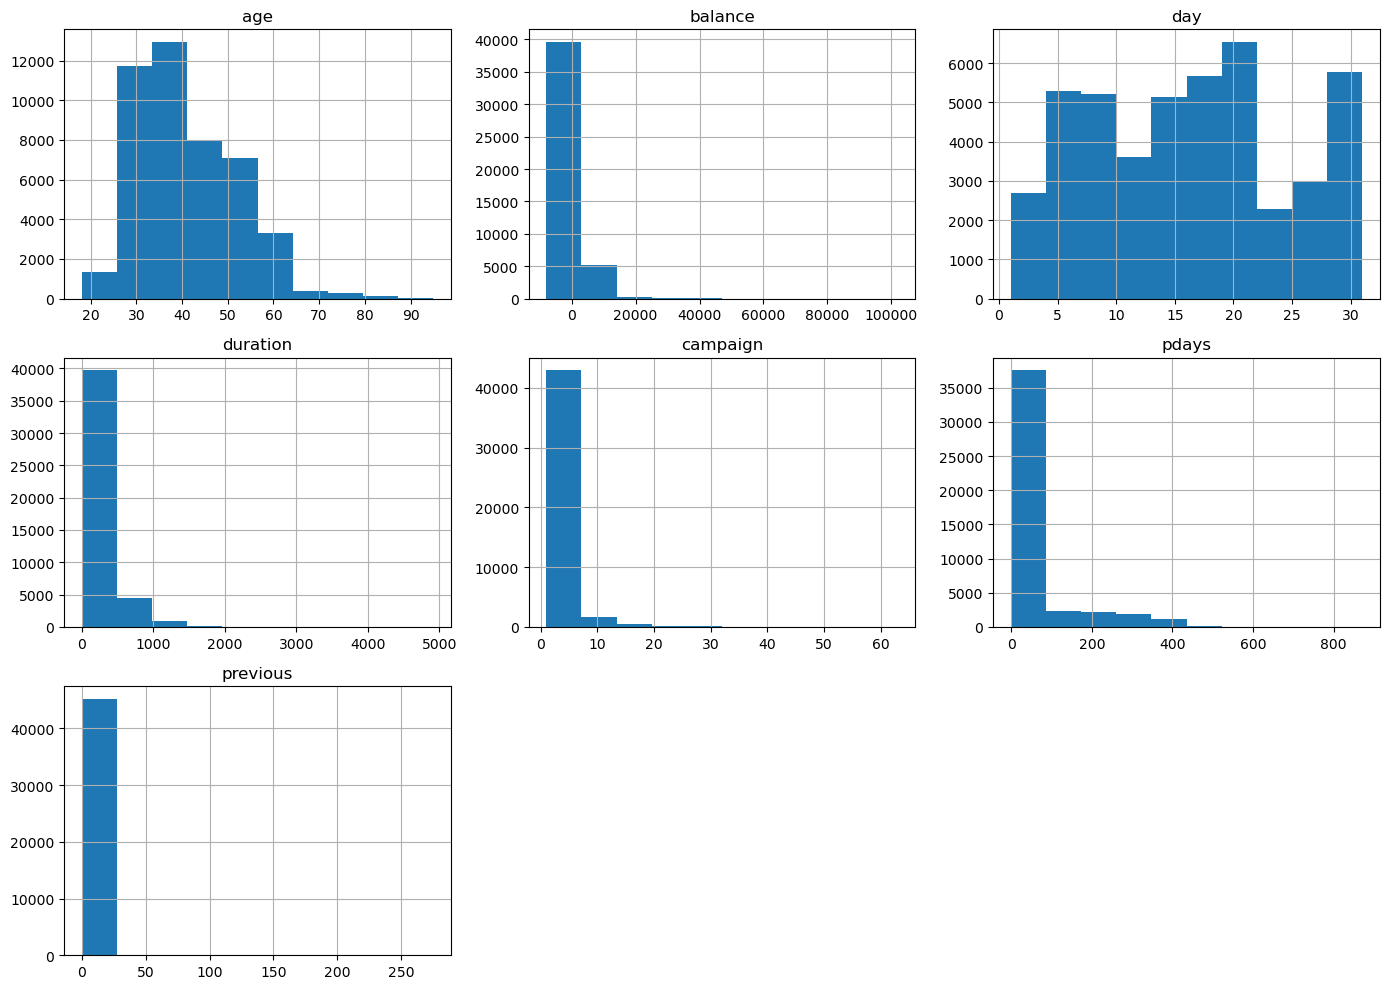

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

14. Distribution of Customer Age

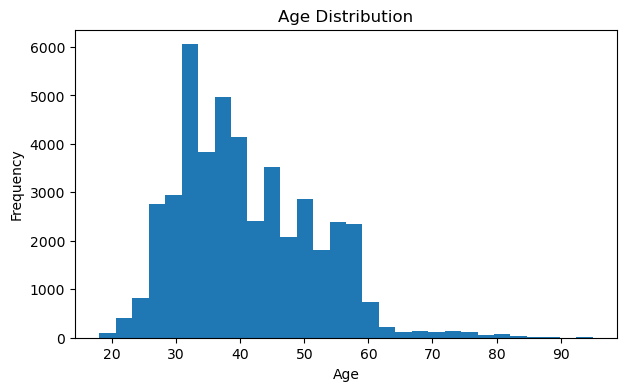

In [19]:
plt.figure(figsize=(7,4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

15. Job Distribution

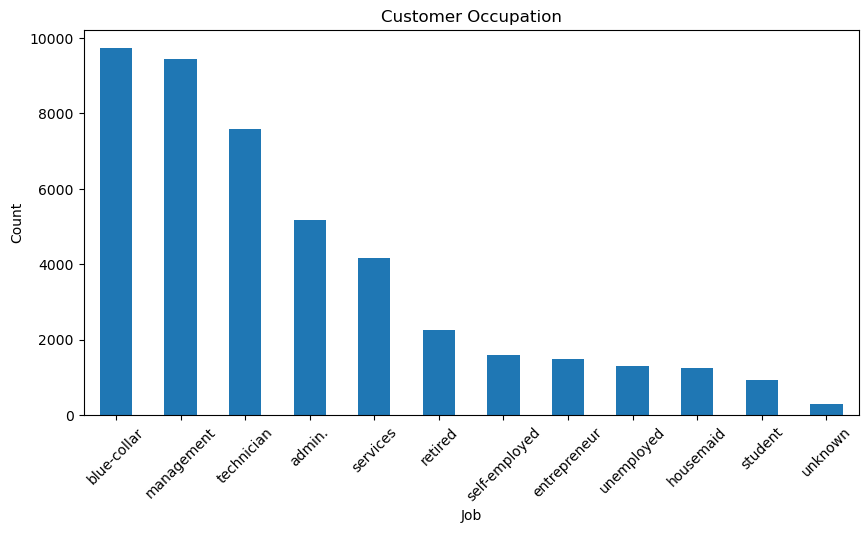

In [20]:
plt.figure(figsize=(10,5))
df["job"].value_counts().plot(kind="bar")
plt.title("Customer Occupation")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

16. Correlation Matrix

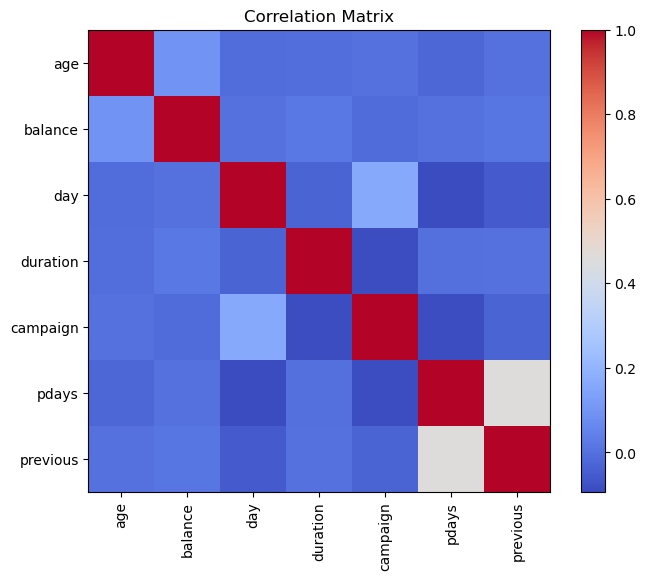

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

17. Initial Findings
According to data analysis performed, number of important observations were found:

1.  This dataset contains 45211 customer records and thus, suitable for machine learning.
2.  This is a classification problem because the target variable is binary.
3.  The dataset contains both numerical and categorical variables, therefore appropriate preprocessing required.
4.  There are no standard missing values, but several categorical features include "unknown" entries that should be handled.
5. The target variable is imbalanced, with more "no" responses than "yes" responses.
6. The numerical features contains different ranges of values, so scaling them could help some machine learning algorithms work better.
7. No severe multicollinearity is FOUND among numerical variables.
8.  The dataset is clean enough for model development after applying suitable preprocessing techniques.